# Notebook 4: Training
Trains the Re-ID model using:
- **Cross-Entropy Loss** — supervised ID classification (from paper Eq.5)
- **Triplet Loss** — metric learning for feature space (from paper Eq.6)
- **Domain Adversarial Loss** — domain-invariant features via GRL (from paper Eq.10)

In [7]:
import os, pickle, random, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
from collections import defaultdict

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [8]:
# Load dataset info
with open('dataset_info.pkl', 'rb') as f:
    info = pickle.load(f)

all_train_samples = info['all_train_samples']
query_samples     = info['query_samples']
gallery_samples   = info['gallery_samples']
NUM_CLASSES       = info['num_classes']
CCTV_ROOT         = info['CCTV_ROOT']

print(f'Train samples : {len(all_train_samples)}')
print(f'Classes       : {NUM_CLASSES}')
print(f'Query         : {len(query_samples)}')
print(f'Gallery       : {len(gallery_samples)}')

Train samples : 14676
Classes       : 465
Query         : 200
Gallery       : 799


## Step 1: Redefine Model & Dataset (self-contained)

In [9]:
# ── Gradient Reversal Layer ────────────────────────────────────────
class GradientReversalFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lambda_):
        ctx.save_for_backward(torch.tensor(lambda_))
        return x.clone()
    @staticmethod
    def backward(ctx, grad_output):
        lambda_, = ctx.saved_tensors
        return -lambda_ * grad_output, None

class GradientReversalLayer(nn.Module):
    def __init__(self, lambda_=1.0):
        super().__init__()
        self.lambda_ = lambda_
    def forward(self, x):
        return GradientReversalFunction.apply(x, self.lambda_)

class DomainClassifier(nn.Module):
    def __init__(self, in_features=2048, hidden=512):
        super().__init__()
        self.grl = GradientReversalLayer(lambda_=1.0)
        self.classifier = nn.Sequential(
            nn.Linear(in_features, hidden), nn.ReLU(),
            nn.Dropout(0.5), nn.Linear(hidden, 2)
        )
    def forward(self, x):
        return self.classifier(self.grl(x))

class ReIDModel(nn.Module):
    def __init__(self, num_classes, feat_dim=2048):
        super().__init__()
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.backbone = nn.Sequential(*list(backbone.children())[:-2])
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.bn  = nn.BatchNorm1d(feat_dim)
        self.bn.bias.requires_grad_(False)
        self.id_classifier = nn.Sequential(
            nn.Linear(feat_dim, 512), nn.ReLU(),
            nn.Dropout(0.5), nn.Linear(512, num_classes)
        )
        self.domain_classifier = DomainClassifier(feat_dim, 512)

    def forward(self, x, return_domain=False):
        feat = self.backbone(x)
        feat = self.gap(feat).view(x.size(0), -1)
        feat = self.bn(feat)
        id_logits = self.id_classifier(feat)
        if return_domain:
            return feat, id_logits, self.domain_classifier(feat)
        return feat, id_logits

    def get_features(self, x):
        feat, _ = self.forward(x)
        return F.normalize(feat, p=2, dim=1)

# ── Datasets ───────────────────────────────────────────────────────
TRAIN_TF = T.Compose([
    T.Resize((256, 128)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
TEST_TF = T.Compose([
    T.Resize((256, 128)), T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

class PRWTrainDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, label

class CCTVTestDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        img_path, pid, cam_id = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, pid, cam_id

print('All classes redefined — ready to train!')

All classes redefined — ready to train!


## Step 2: Define Losses

In [10]:
class TripletLoss(nn.Module):
    """
    Batch-hard triplet loss — from paper Eq.(6).
    For each anchor, finds the hardest positive and hardest negative in the batch.
    """
    def __init__(self, margin=0.3):
        super().__init__()
        self.margin = margin

    def forward(self, features, labels):
        n = features.size(0)
        # Pairwise distance matrix
        dist = torch.cdist(features, features, p=2)  # (N, N)

        labels = labels.unsqueeze(1)  # (N, 1)
        same_id = labels.eq(labels.T)  # (N, N) True where same identity

        # Hardest positive: largest distance among same-ID pairs
        pos_dist = (dist * same_id.float()).max(dim=1)[0]

        # Hardest negative: smallest distance among different-ID pairs
        neg_dist = dist.clone()
        neg_dist[same_id] = float('inf')
        neg_dist = neg_dist.min(dim=1)[0]

        loss = F.relu(pos_dist - neg_dist + self.margin)
        return loss.mean()


ce_loss      = nn.CrossEntropyLoss()
triplet_loss = TripletLoss(margin=0.3)
print('Losses defined!')

Losses defined!


## Step 3: Training Setup

In [11]:
# ── Hyperparameters ────────────────────────────────────────────────
BATCH_SIZE   = 32
NUM_EPOCHS   = 10
# NUM_EPOCHS   = 30
LR           = 3e-4
WEIGHT_DECAY = 5e-4
LAMBDA_DOMAIN = 0.1  # weight for domain loss
LAMBDA_TRIPLET = 1.0 # weight for triplet loss
SAVE_DIR     = 'checkpoints'
os.makedirs(SAVE_DIR, exist_ok=True)

# DataLoaders
train_dataset   = PRWTrainDataset(all_train_samples, TRAIN_TF)
query_dataset   = CCTVTestDataset(query_samples,     TEST_TF)
gallery_dataset = CCTVTestDataset(gallery_samples,   TEST_TF)

train_loader   = DataLoader(train_dataset,   batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
query_loader   = DataLoader(query_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
gallery_loader = DataLoader(gallery_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Model, Optimiser, Scheduler
model     = ReIDModel(num_classes=NUM_CLASSES).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

print(f'Training setup ready!')
print(f'  Epochs      : {NUM_EPOCHS}')
print(f'  Batch size  : {BATCH_SIZE}')
print(f'  LR          : {LR}')
print(f'  Train batches: {len(train_loader)}')

Training setup ready!
  Epochs      : 10
  Batch size  : 32
  LR          : 0.0003
  Train batches: 459


## Step 4: Training Loop

In [12]:
history = {'total': [], 'ce': [], 'triplet': [], 'domain': []}

print('Starting training...\n')
for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    epoch_total = epoch_ce = epoch_triplet = epoch_domain = 0.0
    t0 = time.time()

    for imgs, labels in tqdm(train_loader, desc=f'Epoch {epoch}/{NUM_EPOCHS}', leave=False):
        imgs   = imgs.to(DEVICE)
        labels = labels.to(DEVICE)

        # Assign domain labels: source (PRW) = 0
        domain_labels = torch.zeros(imgs.size(0), dtype=torch.long).to(DEVICE)

        optimizer.zero_grad()

        # Forward pass
        feat, id_logits, dom_logits = model(imgs, return_domain=True)

        # 1. Cross-Entropy Loss (Eq.5 in paper)
        loss_ce = ce_loss(id_logits, labels)

        # 2. Triplet Loss (Eq.6 in paper)
        loss_triplet = triplet_loss(feat, labels)

        # 3. Domain Adversarial Loss (Eq.10 in paper)
        loss_domain = ce_loss(dom_logits, domain_labels)

        # Total loss (Eq.17 in paper)
        loss = loss_ce + LAMBDA_TRIPLET * loss_triplet + LAMBDA_DOMAIN * loss_domain

        loss.backward()
        optimizer.step()

        epoch_total  += loss.item()
        epoch_ce     += loss_ce.item()
        epoch_triplet+= loss_triplet.item()
        epoch_domain += loss_domain.item()

    scheduler.step()

    # Average losses
    n = len(train_loader)
    history['total'].append(epoch_total / n)
    history['ce'].append(epoch_ce / n)
    history['triplet'].append(epoch_triplet / n)
    history['domain'].append(epoch_domain / n)

    elapsed = time.time() - t0
    print(f'Epoch {epoch:02d}/{NUM_EPOCHS} | '
          f'Total: {epoch_total/n:.4f} | '
          f'CE: {epoch_ce/n:.4f} | '
          f'Triplet: {epoch_triplet/n:.4f} | '
          f'Domain: {epoch_domain/n:.4f} | '
          f'Time: {elapsed:.1f}s')

    # Save checkpoint every 5 epochs
    if epoch % 5 == 0:
        ckpt_path = os.path.join(SAVE_DIR, f'model_epoch{epoch:02d}.pth')
        torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                    'optimizer_state': optimizer.state_dict(),
                    'history': history}, ckpt_path)
        print(f'  💾 Checkpoint saved: {ckpt_path}')

# Save final model
torch.save({'epoch': NUM_EPOCHS, 'model_state': model.state_dict(),
            'num_classes': NUM_CLASSES, 'history': history},
           os.path.join(SAVE_DIR, 'model_final.pth'))
print('\n✅ Training complete! Final model saved.')

Starting training...



Epoch 01/10 | Total: 5.4055 | CE: 4.6553 | Triplet: 0.7488 | Domain: 0.0139 | Time: 230.7s


Epoch 02/10 | Total: 2.9319 | CE: 2.6563 | Triplet: 0.2754 | Domain: 0.0016 | Time: 202.8s


Epoch 03/10 | Total: 1.6498 | CE: 1.5456 | Triplet: 0.1040 | Domain: 0.0015 | Time: 181.2s


Epoch 04/10 | Total: 1.1107 | CE: 1.0366 | Triplet: 0.0739 | Domain: 0.0014 | Time: 113.0s


...

Epoch 06/10 | Total: 0.7001 | CE: 0.6597 | Triplet: 0.0402 | Domain: 0.0013 | Time: 113.0s


Epoch 07/10 | Total: 0.5635 | CE: 0.5311 | Triplet: 0.0323 | Domain: 0.0014 | Time: 113.5s


Epoch 08/10 | Total: 0.5077 | CE: 0.4737 | Triplet: 0.0339 | Domain: 0.0014 | Time: 112.4s


Epoch 09/10 | Total: 0.4508 | CE: 0.4268 | Triplet: 0.0238 | Domain: 0.0015 | Time: 113.0s


Epoch 10/10 | Total: 0.4376 | CE: 0.3990 | Triplet: 0.0384 | Domain: 0.0015 | Time: 112.2s
  💾 Checkpoint saved: checkpoints\model_epoch10.pth

✅ Training complete! Final model saved.


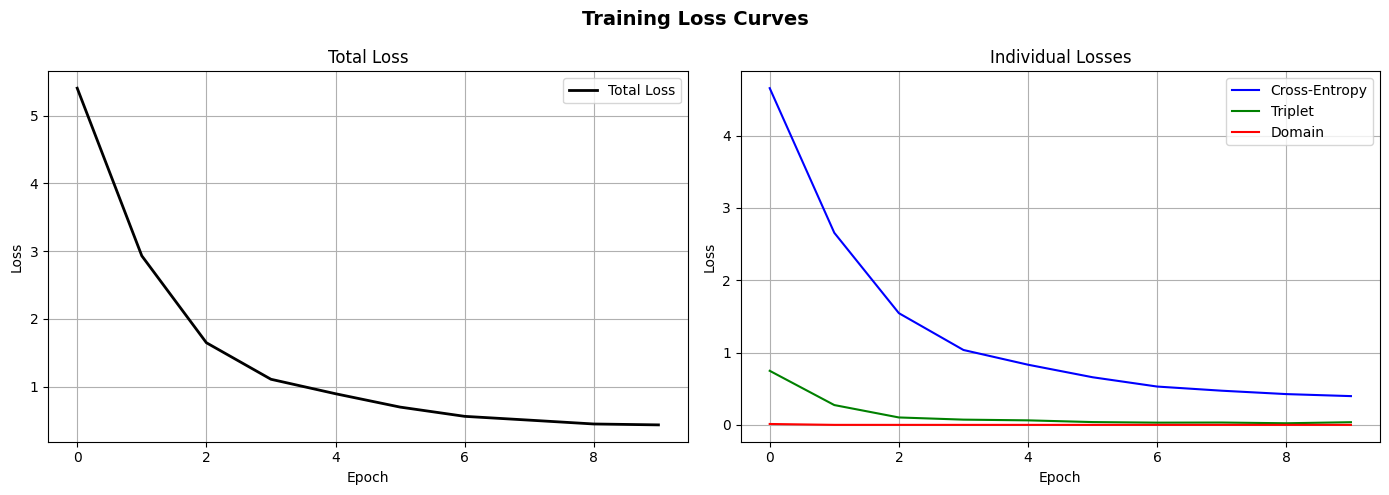

✅ Ready for Notebook 5: Evaluation


In [13]:
# Plot training loss curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training Loss Curves', fontsize=14, fontweight='bold')

axes[0].plot(history['total'], label='Total Loss', color='black', linewidth=2)
axes[0].set_title('Total Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['ce'],      label='Cross-Entropy', color='blue')
axes[1].plot(history['triplet'], label='Triplet',       color='green')
axes[1].plot(history['domain'],  label='Domain',        color='red')
axes[1].set_title('Individual Losses')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print('✅ Ready for Notebook 5: Evaluation')